In [3]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



In [6]:
def loss_fn(params):
    ndnf_sf, sst_sf = params
    summed = EC - (ndnf_sf * NDNF + sst_sf * SST)
    
    # Main loss: how well EC is canceled
    main_loss = np.mean(np.abs(summed))  # or try np.mean(summed**2)

    # Penalty for unequal scale factors
    equal_scaling_penalty = np.abs(ndnf_sf - sst_sf)

    # Total loss = main loss + lambda * penalty
    return main_loss + 50 * equal_scaling_penalty  # adjust 0.1 if needed

def get_dend_VM_cell_type(residual_activity_dict, mean_new_average_vel_array, GLM_params, dend_sf, amplitude=-5, vel=23, norm=False, add_vel_contribution=False, const_vel=True):

    dendrite = np.zeros((50, 58))
    
    dendrite_list = []

    animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))

    for animal in residual_activity_dict:
        for cell in residual_activity_dict[animal]:
            data = residual_activity_dict[animal][cell]
            data = data[:,:58]

            weights = GLM_params[animal][cell]['weights']["Velocity"]
            intercept = GLM_params[animal][cell]['intercept']

            if const_vel:
                animal_velocity = np.full((50, 58), vel)
                
                data = data + (weights * animal_velocity) + intercept
                
                

            elif add_vel_contribution:
                animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))

                data = data + (weights * animal_velocity) + intercept

            # else:
            #     data = data #+ intercept
            #     animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, 58))
                
            if norm == "min_max":
                data = normalize(data, norm='min_max', per_cell=False) * 10

            dendrite += data
            dendrite_list.append(data)

    dendrite = dendrite * dend_sf
    
    return dendrite, animal_velocity, dendrite_list


def get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, filtered_factors_dict):
    new_average_vel = []

    for animal in filtered_factors_dict_EC:
        for cell in filtered_factors_dict_EC[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_EC[animal][cell], axis=1))

    for animal in filtered_factors_dict_SST:
        for cell in filtered_factors_dict_SST[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_SST[animal][cell], axis=1))

    for idx, animal in enumerate(filtered_factors_dict):
        if idx > 8:
            for cell in filtered_factors_dict[animal]:
                new_average_vel.append(np.mean(filtered_factors_dict[animal][cell], axis=1))


    new_average_vel_array = np.array(new_average_vel)
    mean_new_average_vel_array = np.mean(new_average_vel_array, axis=0)
    
    return mean_new_average_vel_array


mean_new_average_vel_array = get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest)

################################# this is the original code for the dendrite model ####################################



from scipy.optimize import minimize


include_inhibition=True

use_model_EC = False

use_residuals= True

#real, nothing or constant
vel_applied = "nothing"

dx = 180/50
    
dend_threshold=20





if vel_applied=="real":

    if use_residuals:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)

    else:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)

elif vel_applied=="constant":
    if use_residuals:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)
        
    else:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)

elif vel_applied=="nothing":
    
    an_velocity = np.zeros((50,53))
    
    if use_residuals:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)
        
    else:
        dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
        
        EC = dend_contribution_EC.copy()
        NDNF = dend_contribution_NDNF.copy()
        SST = dend_contribution_SST.copy()

        result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
        NDNF_sf_opt, SST_sf_opt = result.x
        print("Optimal NDNF_sf:", NDNF_sf_opt)
        print("Optimal SST_sf:", SST_sf_opt)


        
if use_model_EC:

    dend_contribution_EC = np.zeros((summed_dendrite.shape))

    for i in range(dend_contribution_EC.shape[1]):
        for j in range(dend_contribution_EC.shape[0]):
            if j % 2 == 0:
                dend_contribution_EC[j, i] = 1

    print(dend_contribution_EC[:,0])

# NDNF_sf_opt = 3.7960282919084
# SST_sf_opt = 4.108490240597229
    
if include_inhibition:
    summed_dendrite = dend_contribution_EC - (dend_contribution_NDNF*NDNF_sf_opt + dend_contribution_SST*SST_sf_opt)
#     summed_dendrite = dend_contribution_EC - (SST_sf_opt * dend_contribution_SST*2)

else:
    summed_dendrite = dend_contribution_EC

fig, axs = plt.subplots(4, 3, figsize=(15, 15))  
plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals=False, velocity modulation={vel_applied}")
    
im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
axs[1,0].set_title("Dendrite Over Position")
axs[1,0].set_xlabel("Position Bin")
axs[1,0].set_ylabel("Trials")
fig.colorbar(im11, ax=axs[1,0])
    
if include_inhibition: 
    axs[1,2].plot(an_velocity[:,0])
    axs[1,2].set_title("Average Animal Velocity")
    axs[1,2].set_ylabel("meters/sec")
    axs[1,2].set_xlabel("Position Bin")
    
else:
    axs[0,1].plot(an_velocity[:,0])
    axs[0,1].set_title("Average Animal Velocity")
    axs[0,1].set_ylabel("meters/sec")
    axs[0,1].set_xlabel("Position Bin")




mean_dendrite = np.mean(summed_dendrite, axis=1)
sem_dendrite = sem(summed_dendrite, axis=1)

axs[1,1].plot(mean_dendrite, color='k')
axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
axs[1,1].set_title("Trial Averaged Dend Vm")
axs[1,1].set_xlabel("Position Bin")
axs[1,1].set_ylabel("Dendrite Vm")




EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

mean_EC_dend = np.mean(EC_normalized, axis=1)
sem_EC_dend = sem(EC_normalized, axis=1)
axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
axs[0,0].set_title(f"Mean EC Dend Contribution SF={1.0}")
axs[0,0].set_xlabel("Position Bin")
axs[0,0].set_ylabel("Activity")
axs[0,0].set_ylim(0,1)

if include_inhibition:
    
    SST_normalized = dend_contribution_SST/ np.max(dend_contribution_SST)

    mean_SST_dend = np.mean(SST_normalized, axis=1)
    sem_SST_dend = sem(SST_normalized, axis=1)
    axs[0,2].plot(mean_SST_dend, color='b', label="SST Vel")
    axs[0,2].fill_between(range(len(mean_SST_dend)), mean_SST_dend+sem_SST_dend, mean_SST_dend-sem_SST_dend, alpha=0.2, color='b')
    axs[0,2].set_title(f"Mean SST Dend Contribution SF={SST_sf_opt:.3f}")
    axs[0,2].set_xlabel("Position Bin")
    axs[0,2].set_ylabel("Activity")
    axs[0,2].set_ylim(0,1)
    
    NDNF_normalized = dend_contribution_NDNF/ np.max(dend_contribution_NDNF)

    mean_NDNF_dend = np.mean(NDNF_normalized, axis=1)
    sem_NDNF_dend = sem(NDNF_normalized, axis=1)
    axs[0,1].plot(mean_NDNF_dend, color='orange', label="NDNF Vel")
#     axs[0,1].plot(np.zeros(50), color='orange', label="NDNF Vel")
    axs[0,1].fill_between(range(len(mean_NDNF_dend)), mean_NDNF_dend+sem_NDNF_dend, mean_NDNF_dend-sem_NDNF_dend, alpha=0.2, color='orange')
    axs[0,1].set_title(f"Mean NDNF Dend Contribution SF={NDNF_sf_opt:.3f}")
    axs[0,1].set_xlabel("Position Bin")
    axs[0,1].set_ylabel("Activity")
    axs[0,1].set_ylim(0,1)



animal_velocity_constant = np.full((summed_dendrite.shape), 23)
total_time_sec = 4.71657036 

dt=total_time_sec/50
dx=180/50

animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

dt_constant = 0.001
dt = dx / animal_velocity_constant
time_bins = np.cumsum(dt, axis=0)
time_bins_ms = time_bins * 1

num_trials = summed_dendrite.shape[1]
trial_warped_activity = []
max_len = 0

for t in range(num_trials):
    if np.any(np.isnan(time_bins[:, t])):
        continue
    total_time = time_bins[-1, t]

    time_axis_constant = np.arange(0, total_time, dt_constant)
    
    firing = summed_dendrite[:, t]

    warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

    trial_warped_activity.append(warped_firing)
    if len(warped_firing) > max_len:
        max_len = len(warped_firing)
            
padded_warped_activity = np.full((num_trials, max_len), np.nan) 
for i, trace in enumerate(trial_warped_activity):
    padded_warped_activity[i, :len(trace)] = trace

    
    
mean_dend_time = np.mean(padded_warped_activity, axis=0)
sem_dend_time = sem(padded_warped_activity, axis=0)


x_start = 0
time_bin_size_ms=1
num_bins = len(mean_dend_time)
x_end = num_bins * time_bin_size_ms 
im = axs[2,0].imshow(padded_warped_activity, aspect='auto')
axs[2,0].set_title("Dendrite Over Time")
axs[2,0].set_xlabel("Time (ms)")
axs[2,0].set_ylabel("Trials")
fig.colorbar(im, ax=axs[2,0])



# time_bin_size_ms = 100

time_bin_size_ms = 1

num_bins = len(mean_dend_time)
x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms

axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
axs[2,1].set_title("Trial Averaged Dend Vm")
axs[2,1].set_xlabel("Time (ms)")
axs[2,1].set_ylabel("Vm")


position_bins, num_trials = animal_velocity_constant.shape


flat_padded_warped_activity = padded_warped_activity.flatten()
flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

i = 0
while i < len(flat_padded_warped_activity):
    if flat_padded_warped_activity[i] > dend_threshold:
        flat_plateau_array[i:i+300] = 1
        
        i += 800
    else:
        i += 100


plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
axs[2,2].set_xlabel("Time (ms)")
axs[2,2].set_ylabel("Trials")
fig.colorbar(im2, ax=axs[2,2])

plateau_counts_per_time = np.sum(plateau_array, axis=0)
axs[3,0].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
axs[3,0].set_xlabel("Time (ms)")
axs[3,0].set_ylabel("Count")
axs[3,0].set_title("Plateau Counts per Time")


num_time_bins = padded_warped_activity.shape[1]

plateau_positions_counter = np.zeros(50)

time_in_bin_counter = np.zeros(50)

animal_velocity = an_velocity * 100

if vel_applied=="nothing":
    animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100
    

for trial in range(plateau_array.shape[0]):
    
    velocity_trial = animal_velocity[:, trial]  
    
  
    dt_trial = dx / velocity_trial  # in seconds
    time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])
    
    time_bins = np.arange(num_time_bins) * dt_constant  

    for t_idx, time_bin in enumerate(time_bins):
        if plateau_array[trial, t_idx] == 1:
            for pos_idx in range(50):
                if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                    plateau_positions_counter[pos_idx] += 1
                    break

     
    for t_idx, time_bin in enumerate(time_bins):
        for pos_idx in range(50):
            if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                time_in_bin_counter[pos_idx] += 1
                break
                            

axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
axs[3,1].set_title("Plateau Time (ms) per Position Bin")
axs[3,1].set_ylabel("Time (ms)")
axs[3,1].set_xlabel("Position Bin")

bin_size = 10
grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

axs[3,2].bar(range(len(grouped_counts)), grouped_counts)
axs[3,2].set_xticks(np.arange(5), ["0-10", "10-20", "20-30", "30-40", "40-50"])
axs[3,2].set_xlabel(f"Position Bin Groups")
axs[3,2].set_ylabel("Time (ms)")
axs[3,2].set_title("Plateau Time (ms) per Grouped Position Bin")


plt.tight_layout()
plt.show()



########################### this is the single dendrite new version that includes all 3 populations #####################

from scipy.optimize import minimize


include_inhibition=True

def get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=None, constant_vel=None, use_residuals=True, use_model_EC=False, multiple_dendrites=False):

    if use_model_EC:

        dend_contribution_EC = np.zeros((summed_dendrite.shape))

        for i in range(dend_contribution_EC.shape[1]):
            for j in range(dend_contribution_EC.shape[0]):
                if j % 2 == 0:
                    dend_contribution_EC[j, i] = 1

        print(dend_contribution_EC[:,0])

        return dend_contribution_EC
    
    else:
        if use_residuals:
            dend_contribution_EC, an_velocity, dend_list_EC = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_NDNF, an_velocity, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_SST, an_velocity, dend_list_SST = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

        else:
            dend_contribution_EC, an_velocity, dend_list_EC = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_NDNF, an_velocity, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_SST, an_velocity, dend_list_SST = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)
        if multiple_dendrites:
            return dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST
        else:
            return dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity
            
    
    

vel_applied='real'

if vel_applied=="real":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True)
elif vel_applied=="constant":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True)
else:
    constant_vel=False
    real_vel=False
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=False)


def plot_the_dendrite(dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, dend_threshold=20, vel_applied=None):

    dx = 180/50 #track len (cm) / num pos bins
        
    if include_inhibition:
        summed_dendrite = dend_contribution_EC - (dend_contribution_NDNF*NDNF_sf_opt + dend_contribution_SST*SST_sf_opt)
    #     summed_dendrite = dend_contribution_EC - (SST_sf_opt * dend_contribution_SST*2)

    else:
        summed_dendrite = dend_contribution_EC

    fig, axs = plt.subplots(4, 4, figsize=(20, 20))  
    plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals=False, velocity modulation={vel_applied}")
        
    im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
    axs[1,0].set_title("Dendrite Over Position")
    axs[1,0].set_xlabel("Position Bin")
    axs[1,0].set_ylabel("Trials")
    fig.colorbar(im11, ax=axs[1,0])
        
    if include_inhibition: 
        axs[1,2].plot(an_velocity[:,0])
        axs[1,2].set_title("Average Animal Velocity")
        axs[1,2].set_ylabel("meters/sec")
        axs[1,2].set_xlabel("Position Bin")
        
    else:
        axs[0,1].plot(an_velocity[:,0])
        axs[0,1].set_title("Average Animal Velocity")
        axs[0,1].set_ylabel("meters/sec")
        axs[0,1].set_xlabel("Position Bin")

    if vel_applied=='real':
        vel_cm_sec = mean_new_average_vel_array*100
        distance = dx
        axs[1,3].plot(distance/vel_cm_sec)
        axs[1,3].set_ylabel("Occupancy (sec)")
        axs[1,3].set_xlabel("Position Bins")
    elif vel_applied=="constant":
        vel_cm_sec = an_velocity[:,0]*100
        distance = dx
        axs[1,3].plot(distance/vel_cm_sec)
        axs[1,3].set_ylabel("Occupancy (sec)")
        axs[1,3].set_xlabel("Position Bins")
    else:
        vel_cm_sec = mean_new_average_vel_array*100
        distance = dx
        axs[1,3].plot(distance/vel_cm_sec)
        axs[1,3].set_ylabel("Seconds)")
        axs[1,3].set_xlabel("Position Bins")
        axs[1,3].set_title("Average Animal Occupancy")





    mean_dendrite = np.mean(summed_dendrite, axis=1)
    sem_dendrite = sem(summed_dendrite, axis=1)

    axs[1,1].plot(mean_dendrite, color='k')
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
    axs[1,1].set_title("Trial Averaged Dend Vm")
    axs[1,1].set_xlabel("Position Bin")
    axs[1,1].set_ylabel("Dendrite Vm")




    EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

    mean_EC_dend = np.mean(EC_normalized, axis=1)
    sem_EC_dend = sem(EC_normalized, axis=1)
    axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
    axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
    axs[0,0].set_title(f"Mean EC Dend Contribution SF={1.0}")
    axs[0,0].set_xlabel("Position Bin")
    axs[0,0].set_ylabel("Activity")
    axs[0,0].set_ylim(0,1)

    if include_inhibition:
        
        SST_normalized = dend_contribution_SST/ np.max(dend_contribution_SST)

        mean_SST_dend = np.mean(SST_normalized, axis=1)
        sem_SST_dend = sem(SST_normalized, axis=1)
        axs[0,2].plot(mean_SST_dend, color='b', label="SST Vel")
        axs[0,2].fill_between(range(len(mean_SST_dend)), mean_SST_dend+sem_SST_dend, mean_SST_dend-sem_SST_dend, alpha=0.2, color='b')
        axs[0,2].set_title(f"Mean SST Dend Contribution SF={SST_sf_opt:.3f}")
        axs[0,2].set_xlabel("Position Bin")
        axs[0,2].set_ylabel("Activity")
        axs[0,2].set_ylim(0,1)
        
        NDNF_normalized = dend_contribution_NDNF/ np.max(dend_contribution_NDNF)

        mean_NDNF_dend = np.mean(NDNF_normalized, axis=1)
        sem_NDNF_dend = sem(NDNF_normalized, axis=1)
        axs[0,1].plot(mean_NDNF_dend, color='orange', label="NDNF Vel")
    #     axs[0,1].plot(np.zeros(50), color='orange', label="NDNF Vel")
        axs[0,1].fill_between(range(len(mean_NDNF_dend)), mean_NDNF_dend+sem_NDNF_dend, mean_NDNF_dend-sem_NDNF_dend, alpha=0.2, color='orange')
        axs[0,1].set_title(f"Mean NDNF Dend Contribution SF={NDNF_sf_opt:.3f}")
        axs[0,1].set_xlabel("Position Bin")
        axs[0,1].set_ylabel("Activity")
        axs[0,1].set_ylim(0,1)


    animal_velocity_constant = np.full((summed_dendrite.shape), 23)
    total_time_sec = 4.71657036 

    dt=total_time_sec/50
    dx=180/50

    animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

    dt_constant = 0.001
    dt = dx / animal_velocity_constant
    time_bins = np.cumsum(dt, axis=0)
    time_bins_ms = time_bins * 1

    num_trials = summed_dendrite.shape[1]
    trial_warped_activity = []
    max_len = 0

    for t in range(num_trials):
        if np.any(np.isnan(time_bins[:, t])):
            continue
        total_time = time_bins[-1, t]

        time_axis_constant = np.arange(0, total_time, dt_constant)
        
        firing = summed_dendrite[:, t]

        warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

        trial_warped_activity.append(warped_firing)
        if len(warped_firing) > max_len:
            max_len = len(warped_firing)
                
    padded_warped_activity = np.full((num_trials, max_len), np.nan) 
    for i, trace in enumerate(trial_warped_activity):
        padded_warped_activity[i, :len(trace)] = trace

        
        
    mean_dend_time = np.mean(padded_warped_activity, axis=0)
    sem_dend_time = sem(padded_warped_activity, axis=0)


    x_start = 0
    time_bin_size_ms=1
    num_bins = len(mean_dend_time)
    x_end = num_bins * time_bin_size_ms 
    im = axs[2,0].imshow(padded_warped_activity, aspect='auto', interpolation=None)
    axs[2,0].set_title("Dendrite Over Time")
    axs[2,0].set_xlabel("Time (ms)")
    axs[2,0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])



    # time_bin_size_ms = 100

    time_bin_size_ms = 1

    num_bins = len(mean_dend_time)
    x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms

    axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
    axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
    axs[2,1].set_title("Trial Averaged Dend Vm")
    axs[2,1].set_xlabel("Time (ms)")
    axs[2,1].set_ylabel("Vm")


    position_bins, num_trials = animal_velocity_constant.shape


    flat_padded_warped_activity = padded_warped_activity.flatten()
    flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

    just_plateau_starts = np.zeros_like(flat_padded_warped_activity)
    just_plateau_starts_list = []
    i = 0
    while i < len(flat_padded_warped_activity):
        if flat_padded_warped_activity[i] > dend_threshold:
            flat_plateau_array[i:i+300] = 1
            just_plateau_starts[i] = 1
            just_plateau_starts_list.append(i)
            
            i += 800
        else:
            i += 100


    plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

    just_plateau_starts_reshape = just_plateau_starts.reshape(padded_warped_activity.shape)

    just_plateau_starts_sums = np.sum(just_plateau_starts_reshape, axis=1)

    im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
    axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
    axs[2,2].set_xlabel("Time (ms)")
    axs[2,2].set_ylabel("Trials")
    fig.colorbar(im2, ax=axs[2,2])

    axs[2,3].plot(just_plateau_starts_sums)
    axs[2,3].set_title("Plateau Count Over Trials")
    axs[2,3].set_ylabel("Plateau Count")
    axs[2,3].set_xlabel("Fraction of Total Trials")
    axs[2,3].set_xticks([0, len(just_plateau_starts_sums)/2, len(just_plateau_starts_sums) - 1], labels=["0%", "50%", "100%"])

    plateau_counts_per_time = np.sum(plateau_array, axis=0)
    axs[3,0].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
    axs[3,0].set_xlabel("Time (ms)")
    axs[3,0].set_ylabel("Count")
    axs[3,0].set_title("Plateau Counts per Time")


    num_time_bins = padded_warped_activity.shape[1]

    plateau_positions_counter = np.zeros(50)

    plateau_count_position_bin = np.zeros(50)

    time_in_bin_counter = np.zeros(50)

    animal_velocity = an_velocity * 100


    def count_plateaus_by_position_from_abs(plateau_abs_times,       # 1D array, seconds
                                        bin_starts_by_trial,      # shape (n_trials, 51), seconds, relative per trial
                                        trial_starts_abs=None):   # shape (n_trials,), seconds
        plateau_abs_times = np.asarray(plateau_abs_times, float)
        n_trials, n_edges = bin_starts_by_trial.shape
        n_pos_bins = n_edges - 1

        # derive trial starts if not provided (assumes no gaps)
        if trial_starts_abs is None:
            trial_durations = bin_starts_by_trial[:, -1]
            trial_starts_abs = np.concatenate([[0.0], np.cumsum(trial_durations[:-1])])

        counts = np.zeros(n_pos_bins, dtype=int)

        for t in range(n_trials):
            start = trial_starts_abs[t]
            end   = start + bin_starts_by_trial[t, -1]
            mask = (plateau_abs_times >= start) & (plateau_abs_times < end)
            if not np.any(mask):
                continue
            rel = plateau_abs_times[mask] - start  # seconds within this trial

            edges = bin_starts_by_trial[t]  # len 51
            pos_idx = np.searchsorted(edges, rel, side='right') - 1
            pos_idx = np.clip(pos_idx, 0, n_pos_bins-1)
            np.add.at(counts, pos_idx, 1)

        return counts

    




    if vel_applied=="nothing":
        animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100
        
    trial=1
    velocity_trial = animal_velocity[:, trial]  
    dt_trial = dx / velocity_trial  # in seconds
    time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

    just_plateau_starts_list = np.array(just_plateau_starts_list)/1000

    n_trials = 58
    trial_duration = 4.94731308


    time_each_pos_bin_starts = np.array(time_each_pos_bin_starts)

    trial_offsets = np.arange(n_trials) * trial_duration  

    time_each_pos_bin_starts_absolute = time_each_pos_bin_starts[None, :] + trial_offsets[:, None]


    time_each_pos_bin_starts_absolute = time_each_pos_bin_starts_absolute



    
    absolute_plateau_count = np.zeros(50)


    for trial in range(plateau_array.shape[0]):

        
        velocity_trial = animal_velocity[:, trial]  
        
    
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])
        
        time_bins = np.arange(num_time_bins) * dt_constant  

        for t_idx, time_bin in enumerate(time_bins):
            if plateau_array[trial, t_idx] == 1:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_positions_counter[pos_idx] += 1
                        break

        
        for t_idx, time_bin in enumerate(time_bins):
            for pos_idx in range(50):
                if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                    time_in_bin_counter[pos_idx] += 1

        time_pos_bin_starts = time_each_pos_bin_starts_absolute[trial, :]

        for i in range(len(just_plateau_starts_list)):
            plateau_time = just_plateau_starts_list[i]
            for pos_idx in range(50):
                if time_pos_bin_starts[pos_idx] <= plateau_time < time_pos_bin_starts[pos_idx + 1]:
                    absolute_plateau_count[pos_idx] += 1


    axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
    axs[3,1].set_title("Plateau Time (ms) per Position Bin")
    axs[3,1].set_ylabel("Time (ms)")
    axs[3,1].set_xlabel("Position Bin")

    # bin_size = 5
    # grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

    axs[3,2].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
    # axs[3,2].set_xticks(np.arange(5), ["0-10", "10-20", "20-30", "30-40", "40-50"])
    axs[3,2].set_xlabel(f"Position Bin Groups")
    axs[3,2].set_ylabel("Time (ms)")
    axs[3,2].set_title("Plateau Time (ms) per Grouped Position Bin")

    # grouped_counts = [np.sum(absolute_plateau_count[i:i+bin_size]) for i in range(0, len(absolute_plateau_count), bin_size)]

    axs[3,3].bar(range(len(absolute_plateau_count)), absolute_plateau_count)
    axs[3,3].set_title("Plateau Onset Count per Position Bin")
    axs[3,3].set_ylabel("Count")
    axs[3,3].set_xlabel("Position Bin")
    

    plt.tight_layout()
    plt.show()

plot_the_dendrite(dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, dend_threshold=180)


Optimal NDNF_sf: 3.1010301208432027
Optimal SST_sf: 3.101030118265799


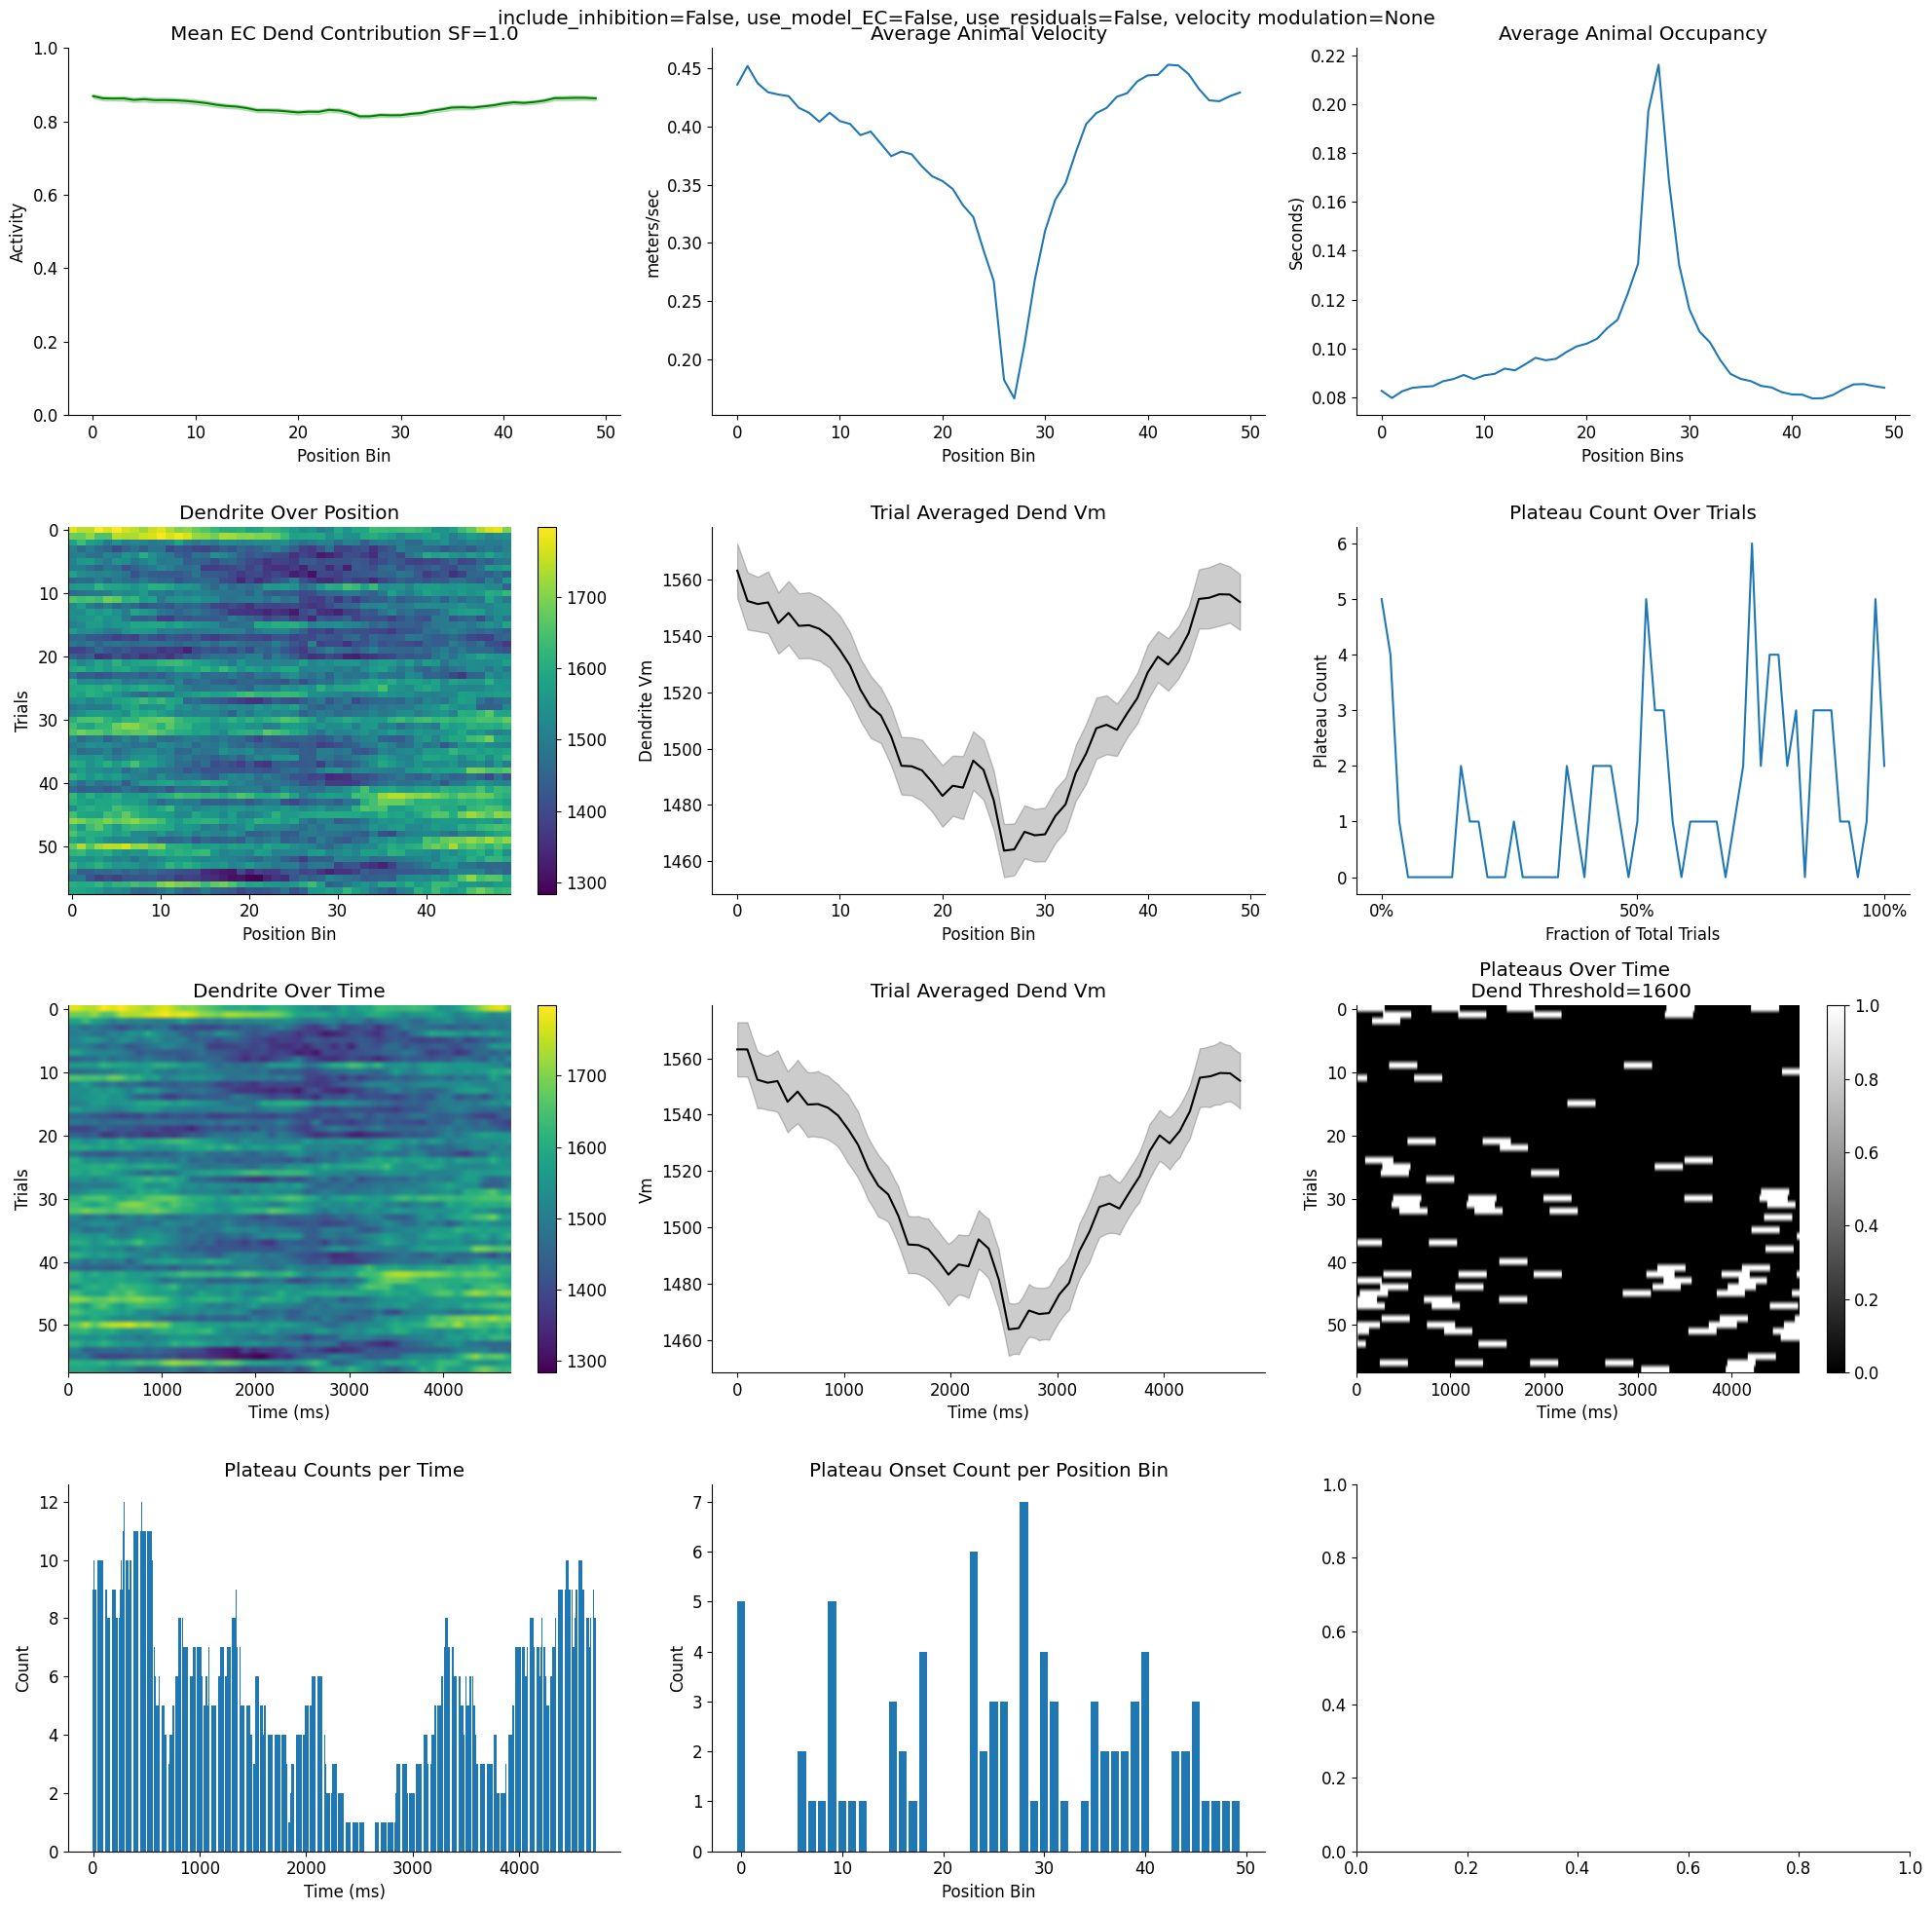

In [83]:
from scipy.optimize import minimize


include_inhibition=True

def get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=None, constant_vel=None, use_residuals=True, use_model_EC=False, multiple_dendrites=False):

    if use_model_EC:

        dend_contribution_EC = np.zeros((summed_dendrite.shape))

        for i in range(dend_contribution_EC.shape[1]):
            for j in range(dend_contribution_EC.shape[0]):
                if j % 2 == 0:
                    dend_contribution_EC[j, i] = 1

        print(dend_contribution_EC[:,0])

        return dend_contribution_EC
    
    else:
        if use_residuals:
            dend_contribution_EC, an_velocity, dend_list_EC = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_NDNF, an_velocity, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_SST, an_velocity, dend_list_SST = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

        else:
            dend_contribution_EC, an_velocity, dend_list_EC = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_NDNF, an_velocity, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            dend_contribution_SST, an_velocity, dend_list_SST = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)
        if multiple_dendrites:
            return dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST
        else:
            return dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity
            
    
    

vel_applied='real'

if vel_applied=="real":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True)
elif vel_applied=="constant":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True)
else:
    constant_vel=False
    real_vel=False
    dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=False)


def plot_the_dendrite(dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, dend_threshold=20, vel_applied=None, include_inhibition=False):

    dx = 180/50 #track len (cm) / num pos bins
        
    if include_inhibition:
        summed_dendrite = dend_contribution_EC - (dend_contribution_NDNF*NDNF_sf_opt + dend_contribution_SST*SST_sf_opt)
    #     summed_dendrite = dend_contribution_EC - (SST_sf_opt * dend_contribution_SST*2)

    else:
        summed_dendrite = dend_contribution_EC


    if include_inhibition:

        fig, axs = plt.subplots(4, 4, figsize=(20, 20))  
        plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals=False, velocity modulation={vel_applied}")
            
        im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
        axs[1,0].set_title("Dendrite Over Position")
        axs[1,0].set_xlabel("Position Bin")
        axs[1,0].set_ylabel("Trials")
        fig.colorbar(im11, ax=axs[1,0])
            
        if include_inhibition: 
            axs[1,2].plot(an_velocity[:,0])
            axs[1,2].set_title("Average Animal Velocity")
            axs[1,2].set_ylabel("meters/sec")
            axs[1,2].set_xlabel("Position Bin")
            
        else:
            axs[0,1].plot(an_velocity[:,0])
            axs[0,1].set_title("Average Animal Velocity")
            axs[0,1].set_ylabel("meters/sec")
            axs[0,1].set_xlabel("Position Bin")

        if vel_applied=='real':
            vel_cm_sec = mean_new_average_vel_array*100
            distance = dx
            axs[1,3].plot(distance/vel_cm_sec)
            axs[1,3].set_ylabel("Occupancy (sec)")
            axs[1,3].set_xlabel("Position Bins")
        elif vel_applied=="constant":
            vel_cm_sec = an_velocity[:,0]*100
            distance = dx
            axs[1,3].plot(distance/vel_cm_sec)
            axs[1,3].set_ylabel("Occupancy (sec)")
            axs[1,3].set_xlabel("Position Bins")
        else:
            vel_cm_sec = mean_new_average_vel_array*100
            distance = dx
            axs[1,3].plot(distance/vel_cm_sec)
            axs[1,3].set_ylabel("Seconds)")
            axs[1,3].set_xlabel("Position Bins")
            axs[1,3].set_title("Average Animal Occupancy")





        mean_dendrite = np.mean(summed_dendrite, axis=1)
        sem_dendrite = sem(summed_dendrite, axis=1)

        axs[1,1].plot(mean_dendrite, color='k')
        axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
        axs[1,1].set_title("Trial Averaged Dend Vm")
        axs[1,1].set_xlabel("Position Bin")
        axs[1,1].set_ylabel("Dendrite Vm")




        EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

        mean_EC_dend = np.mean(EC_normalized, axis=1)
        sem_EC_dend = sem(EC_normalized, axis=1)
        axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
        axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
        axs[0,0].set_title(f"Mean EC Dend Contribution SF={1.0}")
        axs[0,0].set_xlabel("Position Bin")
        axs[0,0].set_ylabel("Activity")
        axs[0,0].set_ylim(0,1)

        if include_inhibition:
            
            SST_normalized = dend_contribution_SST/ np.max(dend_contribution_SST)

            mean_SST_dend = np.mean(SST_normalized, axis=1)
            sem_SST_dend = sem(SST_normalized, axis=1)
            axs[0,2].plot(mean_SST_dend, color='b', label="SST Vel")
            axs[0,2].fill_between(range(len(mean_SST_dend)), mean_SST_dend+sem_SST_dend, mean_SST_dend-sem_SST_dend, alpha=0.2, color='b')
            axs[0,2].set_title(f"Mean SST Dend Contribution SF={SST_sf_opt:.3f}")
            axs[0,2].set_xlabel("Position Bin")
            axs[0,2].set_ylabel("Activity")
            axs[0,2].set_ylim(0,1)
            
            NDNF_normalized = dend_contribution_NDNF/ np.max(dend_contribution_NDNF)

            mean_NDNF_dend = np.mean(NDNF_normalized, axis=1)
            sem_NDNF_dend = sem(NDNF_normalized, axis=1)
            axs[0,1].plot(mean_NDNF_dend, color='orange', label="NDNF Vel")
        #     axs[0,1].plot(np.zeros(50), color='orange', label="NDNF Vel")
            axs[0,1].fill_between(range(len(mean_NDNF_dend)), mean_NDNF_dend+sem_NDNF_dend, mean_NDNF_dend-sem_NDNF_dend, alpha=0.2, color='orange')
            axs[0,1].set_title(f"Mean NDNF Dend Contribution SF={NDNF_sf_opt:.3f}")
            axs[0,1].set_xlabel("Position Bin")
            axs[0,1].set_ylabel("Activity")
            axs[0,1].set_ylim(0,1)


        animal_velocity_constant = np.full((summed_dendrite.shape), 23)
        total_time_sec = 4.71657036 

        dt=total_time_sec/50
        dx=180/50

        animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

        dt_constant = 0.001
        dt = dx / animal_velocity_constant
        time_bins = np.cumsum(dt, axis=0)
        time_bins_ms = time_bins * 1

        num_trials = summed_dendrite.shape[1]
        trial_warped_activity = []
        max_len = 0

        for t in range(num_trials):
            if np.any(np.isnan(time_bins[:, t])):
                continue
            total_time = time_bins[-1, t]

            time_axis_constant = np.arange(0, total_time, dt_constant)
            
            firing = summed_dendrite[:, t]

            warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

            trial_warped_activity.append(warped_firing)
            if len(warped_firing) > max_len:
                max_len = len(warped_firing)
                    
        padded_warped_activity = np.full((num_trials, max_len), np.nan) 
        for i, trace in enumerate(trial_warped_activity):
            padded_warped_activity[i, :len(trace)] = trace

            
            
        mean_dend_time = np.mean(padded_warped_activity, axis=0)
        sem_dend_time = sem(padded_warped_activity, axis=0)


        x_start = 0
        time_bin_size_ms=1
        num_bins = len(mean_dend_time)
        x_end = num_bins * time_bin_size_ms 
        im = axs[2,0].imshow(padded_warped_activity, aspect='auto', interpolation=None)
        axs[2,0].set_title("Dendrite Over Time")
        axs[2,0].set_xlabel("Time (ms)")
        axs[2,0].set_ylabel("Trials")
        fig.colorbar(im, ax=axs[2,0])



        # time_bin_size_ms = 100

        time_bin_size_ms = 1

        num_bins = len(mean_dend_time)
        x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms

        axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
        axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
        axs[2,1].set_title("Trial Averaged Dend Vm")
        axs[2,1].set_xlabel("Time (ms)")
        axs[2,1].set_ylabel("Vm")


        position_bins, num_trials = animal_velocity_constant.shape


        flat_padded_warped_activity = padded_warped_activity.flatten()
        flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

        just_plateau_starts = np.zeros_like(flat_padded_warped_activity)
        just_plateau_starts_list = []
        i = 0
        while i < len(flat_padded_warped_activity):
            if flat_padded_warped_activity[i] > dend_threshold:
                flat_plateau_array[i:i+300] = 1
                just_plateau_starts[i] = 1
                just_plateau_starts_list.append(i)
                
                i += 800
            else:
                i += 100


        plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

        just_plateau_starts_reshape = just_plateau_starts.reshape(padded_warped_activity.shape)

        just_plateau_starts_sums = np.sum(just_plateau_starts_reshape, axis=1)

        im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
        axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
        axs[2,2].set_xlabel("Time (ms)")
        axs[2,2].set_ylabel("Trials")
        fig.colorbar(im2, ax=axs[2,2])

        axs[2,3].plot(just_plateau_starts_sums)
        axs[2,3].set_title("Plateau Count Over Trials")
        axs[2,3].set_ylabel("Plateau Count")
        axs[2,3].set_xlabel("Fraction of Total Trials")
        axs[2,3].set_xticks([0, len(just_plateau_starts_sums)/2, len(just_plateau_starts_sums) - 1], labels=["0%", "50%", "100%"])

        plateau_counts_per_time = np.sum(plateau_array, axis=0)
        axs[3,0].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
        axs[3,0].set_xlabel("Time (ms)")
        axs[3,0].set_ylabel("Count")
        axs[3,0].set_title("Plateau Counts per Time")


        num_time_bins = padded_warped_activity.shape[1]

        plateau_positions_counter = np.zeros(50)

        plateau_count_position_bin = np.zeros(50)

        time_in_bin_counter = np.zeros(50)

        animal_velocity = an_velocity * 100


        def count_plateaus_by_position_from_abs(plateau_abs_times,       # 1D array, seconds
                                            bin_starts_by_trial,      # shape (n_trials, 51), seconds, relative per trial
                                            trial_starts_abs=None):   # shape (n_trials,), seconds
            plateau_abs_times = np.asarray(plateau_abs_times, float)
            n_trials, n_edges = bin_starts_by_trial.shape
            n_pos_bins = n_edges - 1

            # derive trial starts if not provided (assumes no gaps)
            if trial_starts_abs is None:
                trial_durations = bin_starts_by_trial[:, -1]
                trial_starts_abs = np.concatenate([[0.0], np.cumsum(trial_durations[:-1])])

            counts = np.zeros(n_pos_bins, dtype=int)

            for t in range(n_trials):
                start = trial_starts_abs[t]
                end   = start + bin_starts_by_trial[t, -1]
                mask = (plateau_abs_times >= start) & (plateau_abs_times < end)
                if not np.any(mask):
                    continue
                rel = plateau_abs_times[mask] - start  # seconds within this trial

                edges = bin_starts_by_trial[t]  # len 51
                pos_idx = np.searchsorted(edges, rel, side='right') - 1
                pos_idx = np.clip(pos_idx, 0, n_pos_bins-1)
                np.add.at(counts, pos_idx, 1)

            return counts

        




        if vel_applied=="nothing":
            animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100
            
        trial=1
        velocity_trial = animal_velocity[:, trial]  
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        just_plateau_starts_list = np.array(just_plateau_starts_list)/1000

        n_trials = 58
        trial_duration = 4.94731308


        time_each_pos_bin_starts = np.array(time_each_pos_bin_starts)

        trial_offsets = np.arange(n_trials) * trial_duration  

        time_each_pos_bin_starts_absolute = time_each_pos_bin_starts[None, :] + trial_offsets[:, None]


        time_each_pos_bin_starts_absolute = time_each_pos_bin_starts_absolute



        
        absolute_plateau_count = np.zeros(50)


        for trial in range(plateau_array.shape[0]):

            
            velocity_trial = animal_velocity[:, trial]  
            
        
            dt_trial = dx / velocity_trial  # in seconds
            time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])
            
            time_bins = np.arange(num_time_bins) * dt_constant  

            for t_idx, time_bin in enumerate(time_bins):
                if plateau_array[trial, t_idx] == 1:
                    for pos_idx in range(50):
                        if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                            plateau_positions_counter[pos_idx] += 1
                            break

            
            for t_idx, time_bin in enumerate(time_bins):
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                        time_in_bin_counter[pos_idx] += 1

            time_pos_bin_starts = time_each_pos_bin_starts_absolute[trial, :]

            for i in range(len(just_plateau_starts_list)):
                plateau_time = just_plateau_starts_list[i]
                for pos_idx in range(50):
                    if time_pos_bin_starts[pos_idx] <= plateau_time < time_pos_bin_starts[pos_idx + 1]:
                        absolute_plateau_count[pos_idx] += 1


        axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
        axs[3,1].set_title("Plateau Time (ms) per Position Bin")
        axs[3,1].set_ylabel("Time (ms)")
        axs[3,1].set_xlabel("Position Bin")

        # bin_size = 5
        # grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

        axs[3,2].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
        # axs[3,2].set_xticks(np.arange(5), ["0-10", "10-20", "20-30", "30-40", "40-50"])
        axs[3,2].set_xlabel(f"Position Bin Groups")
        axs[3,2].set_ylabel("Time (ms)")
        axs[3,2].set_title("Plateau Time (ms) per Grouped Position Bin")

        # grouped_counts = [np.sum(absolute_plateau_count[i:i+bin_size]) for i in range(0, len(absolute_plateau_count), bin_size)]

        axs[3,3].bar(range(len(absolute_plateau_count)), absolute_plateau_count)
        axs[3,3].set_title("Plateau Onset Count per Position Bin")
        axs[3,3].set_ylabel("Count")
        axs[3,3].set_xlabel("Position Bin")

    else:
        fig, axs = plt.subplots(4,3, figsize=(20, 20))  
        plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals=False, velocity modulation={vel_applied}")
            
        im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
        axs[1,0].set_title("Dendrite Over Position")
        axs[1,0].set_xlabel("Position Bin")
        axs[1,0].set_ylabel("Trials")
        fig.colorbar(im11, ax=axs[1,0])

        axs[0,1].plot(an_velocity[:,0])
        axs[0,1].set_title("Average Animal Velocity")
        axs[0,1].set_ylabel("meters/sec")
        axs[0,1].set_xlabel("Position Bin")
        


        if vel_applied=='real':
            vel_cm_sec = mean_new_average_vel_array*100
            distance = dx
            axs[0,2].plot(distance/vel_cm_sec)
            axs[0,2].set_ylabel("Occupancy (sec)")
            axs[0,2].set_xlabel("Position Bins")
        elif vel_applied=="constant":
            vel_cm_sec = an_velocity[:,0]*100
            distance = dx
            axs[0,2].plot(distance/vel_cm_sec)
            axs[0,2].set_ylabel("Occupancy (sec)")
            axs[0,2].set_xlabel("Position Bins")
        else:
            vel_cm_sec = mean_new_average_vel_array*100
            distance = dx
            axs[0,2].plot(distance/vel_cm_sec)
            axs[0,2].set_ylabel("Seconds)")
            axs[0,2].set_xlabel("Position Bins")
            axs[0,2].set_title("Average Animal Occupancy")





        mean_dendrite = np.mean(summed_dendrite, axis=1)
        sem_dendrite = sem(summed_dendrite, axis=1)

        axs[1,1].plot(mean_dendrite, color='k')
        axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
        axs[1,1].set_title("Trial Averaged Dend Vm")
        axs[1,1].set_xlabel("Position Bin")
        axs[1,1].set_ylabel("Dendrite Vm")




        EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

        mean_EC_dend = np.mean(EC_normalized, axis=1)
        sem_EC_dend = sem(EC_normalized, axis=1)
        axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
        axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
        axs[0,0].set_title(f"Mean EC Dend Contribution SF={1.0}")
        axs[0,0].set_xlabel("Position Bin")
        axs[0,0].set_ylabel("Activity")
        axs[0,0].set_ylim(0,1)


        animal_velocity_constant = np.full((summed_dendrite.shape), 23)
        total_time_sec = 4.71657036 

        dt=total_time_sec/50
        dx=180/50

        animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

        dt_constant = 0.001
        dt = dx / animal_velocity_constant
        time_bins = np.cumsum(dt, axis=0)
        time_bins_ms = time_bins * 1

        num_trials = summed_dendrite.shape[1]
        trial_warped_activity = []
        max_len = 0

        for t in range(num_trials):
            if np.any(np.isnan(time_bins[:, t])):
                continue
            total_time = time_bins[-1, t]

            time_axis_constant = np.arange(0, total_time, dt_constant)
            
            firing = summed_dendrite[:, t]

            warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

            trial_warped_activity.append(warped_firing)
            if len(warped_firing) > max_len:
                max_len = len(warped_firing)
                    
        padded_warped_activity = np.full((num_trials, max_len), np.nan) 
        for i, trace in enumerate(trial_warped_activity):
            padded_warped_activity[i, :len(trace)] = trace

            
            
        mean_dend_time = np.mean(padded_warped_activity, axis=0)
        sem_dend_time = sem(padded_warped_activity, axis=0)


        x_start = 0
        time_bin_size_ms=1
        num_bins = len(mean_dend_time)
        x_end = num_bins * time_bin_size_ms 
        im = axs[2,0].imshow(padded_warped_activity, aspect='auto', interpolation=None)
        axs[2,0].set_title("Dendrite Over Time")
        axs[2,0].set_xlabel("Time (ms)")
        axs[2,0].set_ylabel("Trials")
        fig.colorbar(im, ax=axs[2,0])



        # time_bin_size_ms = 100

        time_bin_size_ms = 1

        num_bins = len(mean_dend_time)
        x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms

        axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
        axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
        axs[2,1].set_title("Trial Averaged Dend Vm")
        axs[2,1].set_xlabel("Time (ms)")
        axs[2,1].set_ylabel("Vm")


        position_bins, num_trials = animal_velocity_constant.shape


        flat_padded_warped_activity = padded_warped_activity.flatten()
        flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

        just_plateau_starts = np.zeros_like(flat_padded_warped_activity)
        just_plateau_starts_list = []
        i = 0
        while i < len(flat_padded_warped_activity):
            if flat_padded_warped_activity[i] > dend_threshold:
                flat_plateau_array[i:i+300] = 1
                just_plateau_starts[i] = 1
                just_plateau_starts_list.append(i)
                
                i += 800
            else:
                i += 100


        plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

        just_plateau_starts_reshape = just_plateau_starts.reshape(padded_warped_activity.shape)

        just_plateau_starts_sums = np.sum(just_plateau_starts_reshape, axis=1)

        im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
        axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
        axs[2,2].set_xlabel("Time (ms)")
        axs[2,2].set_ylabel("Trials")
        fig.colorbar(im2, ax=axs[2,2])

        axs[1,2].plot(just_plateau_starts_sums)
        axs[1,2].set_title("Plateau Count Over Trials")
        axs[1,2].set_ylabel("Plateau Count")
        axs[1,2].set_xlabel("Fraction of Total Trials")
        axs[1,2].set_xticks([0, len(just_plateau_starts_sums)/2, len(just_plateau_starts_sums) - 1], labels=["0%", "50%", "100%"])

        # plateau_counts_per_time = np.sum(plateau_array, axis=0)
        # axs[1,2].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
        # axs[1,2].set_xlabel("Time (ms)")
        # axs[1,2].set_ylabel("Count")
        # axs[1,2].set_title("Plateau Counts per Time")


        num_time_bins = padded_warped_activity.shape[1]

        plateau_positions_counter = np.zeros(50)

        plateau_count_position_bin = np.zeros(50)

        time_in_bin_counter = np.zeros(50)

        animal_velocity = an_velocity * 100


        def count_plateaus_by_position_from_abs(plateau_abs_times,       # 1D array, seconds
                                            bin_starts_by_trial,      # shape (n_trials, 51), seconds, relative per trial
                                            trial_starts_abs=None):   # shape (n_trials,), seconds
            plateau_abs_times = np.asarray(plateau_abs_times, float)
            n_trials, n_edges = bin_starts_by_trial.shape
            n_pos_bins = n_edges - 1

            # derive trial starts if not provided (assumes no gaps)
            if trial_starts_abs is None:
                trial_durations = bin_starts_by_trial[:, -1]
                trial_starts_abs = np.concatenate([[0.0], np.cumsum(trial_durations[:-1])])

            counts = np.zeros(n_pos_bins, dtype=int)

            for t in range(n_trials):
                start = trial_starts_abs[t]
                end   = start + bin_starts_by_trial[t, -1]
                mask = (plateau_abs_times >= start) & (plateau_abs_times < end)
                if not np.any(mask):
                    continue
                rel = plateau_abs_times[mask] - start  # seconds within this trial

                edges = bin_starts_by_trial[t]  # len 51
                pos_idx = np.searchsorted(edges, rel, side='right') - 1
                pos_idx = np.clip(pos_idx, 0, n_pos_bins-1)
                np.add.at(counts, pos_idx, 1)

            return counts

    




        if vel_applied=="nothing":
            animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100
            
        trial=1
        velocity_trial = animal_velocity[:, trial]  
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        just_plateau_starts_list = np.array(just_plateau_starts_list)/1000

        n_trials = 58
        trial_duration = 4.94731308


        time_each_pos_bin_starts = np.array(time_each_pos_bin_starts)

        trial_offsets = np.arange(n_trials) * trial_duration  

        time_each_pos_bin_starts_absolute = time_each_pos_bin_starts[None, :] + trial_offsets[:, None]


        time_each_pos_bin_starts_absolute = time_each_pos_bin_starts_absolute



        
        absolute_plateau_count = np.zeros(50)


        for trial in range(plateau_array.shape[0]):

            
            velocity_trial = animal_velocity[:, trial]  
            
        
            dt_trial = dx / velocity_trial  # in seconds
            time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])
            
            time_bins = np.arange(num_time_bins) * dt_constant  

            for t_idx, time_bin in enumerate(time_bins):
                if plateau_array[trial, t_idx] == 1:
                    for pos_idx in range(50):
                        if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                            plateau_positions_counter[pos_idx] += 1
                            break

            
            for t_idx, time_bin in enumerate(time_bins):
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                        time_in_bin_counter[pos_idx] += 1

            time_pos_bin_starts = time_each_pos_bin_starts_absolute[trial, :]

            for i in range(len(just_plateau_starts_list)):
                plateau_time = just_plateau_starts_list[i]
                for pos_idx in range(50):
                    if time_pos_bin_starts[pos_idx] <= plateau_time < time_pos_bin_starts[pos_idx + 1]:
                        absolute_plateau_count[pos_idx] += 1


        # axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
        # axs[3,1].set_title("Plateau Time (ms) per Position Bin")
        # axs[3,1].set_ylabel("Time (ms)")
        # axs[3,1].set_xlabel("Position Bin")

        # # bin_size = 5
        # # grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

        # axs[3,2].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
        # # axs[3,2].set_xticks(np.arange(5), ["0-10", "10-20", "20-30", "30-40", "40-50"])
        # axs[3,2].set_xlabel(f"Position Bin Groups")
        # axs[3,2].set_ylabel("Time (ms)")
        # axs[3,2].set_title("Plateau Time (ms) per Grouped Position Bin")

        # grouped_counts = [np.sum(absolute_plateau_count[i:i+bin_size]) for i in range(0, len(absolute_plateau_count), bin_size)]

        plateau_counts_per_time = np.sum(plateau_array, axis=0)
        axs[3,0].bar(range(len(plateau_counts_per_time)), plateau_counts_per_time)
        axs[3,0].set_xlabel("Time (ms)")
        axs[3,0].set_ylabel("Count")
        axs[3,0].set_title("Plateau Counts per Time")

        axs[3,1].bar(range(len(absolute_plateau_count)), absolute_plateau_count)
        axs[3,1].set_title("Plateau Onset Count per Position Bin")
        axs[3,1].set_ylabel("Count")
        axs[3,1].set_xlabel("Position Bin")


            

        plt.tight_layout()
        plt.show()
    

plot_the_dendrite(dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, dend_threshold=1600, include_inhibition=False)


Optimal NDNF_sf: 3.1010301208432027
Optimal SST_sf: 3.101030118265799
EC_input_matrix (792, 50, 58)
EC_input_matrix.shape (792, 50, 58)
NDNF_sf_opt: 0.20443436876441803
SST_sf_opt: 0.20443437450923402
means 0.999862211348013 mean_dend_activity 79.98703377198783
variance_array.shape (100,)


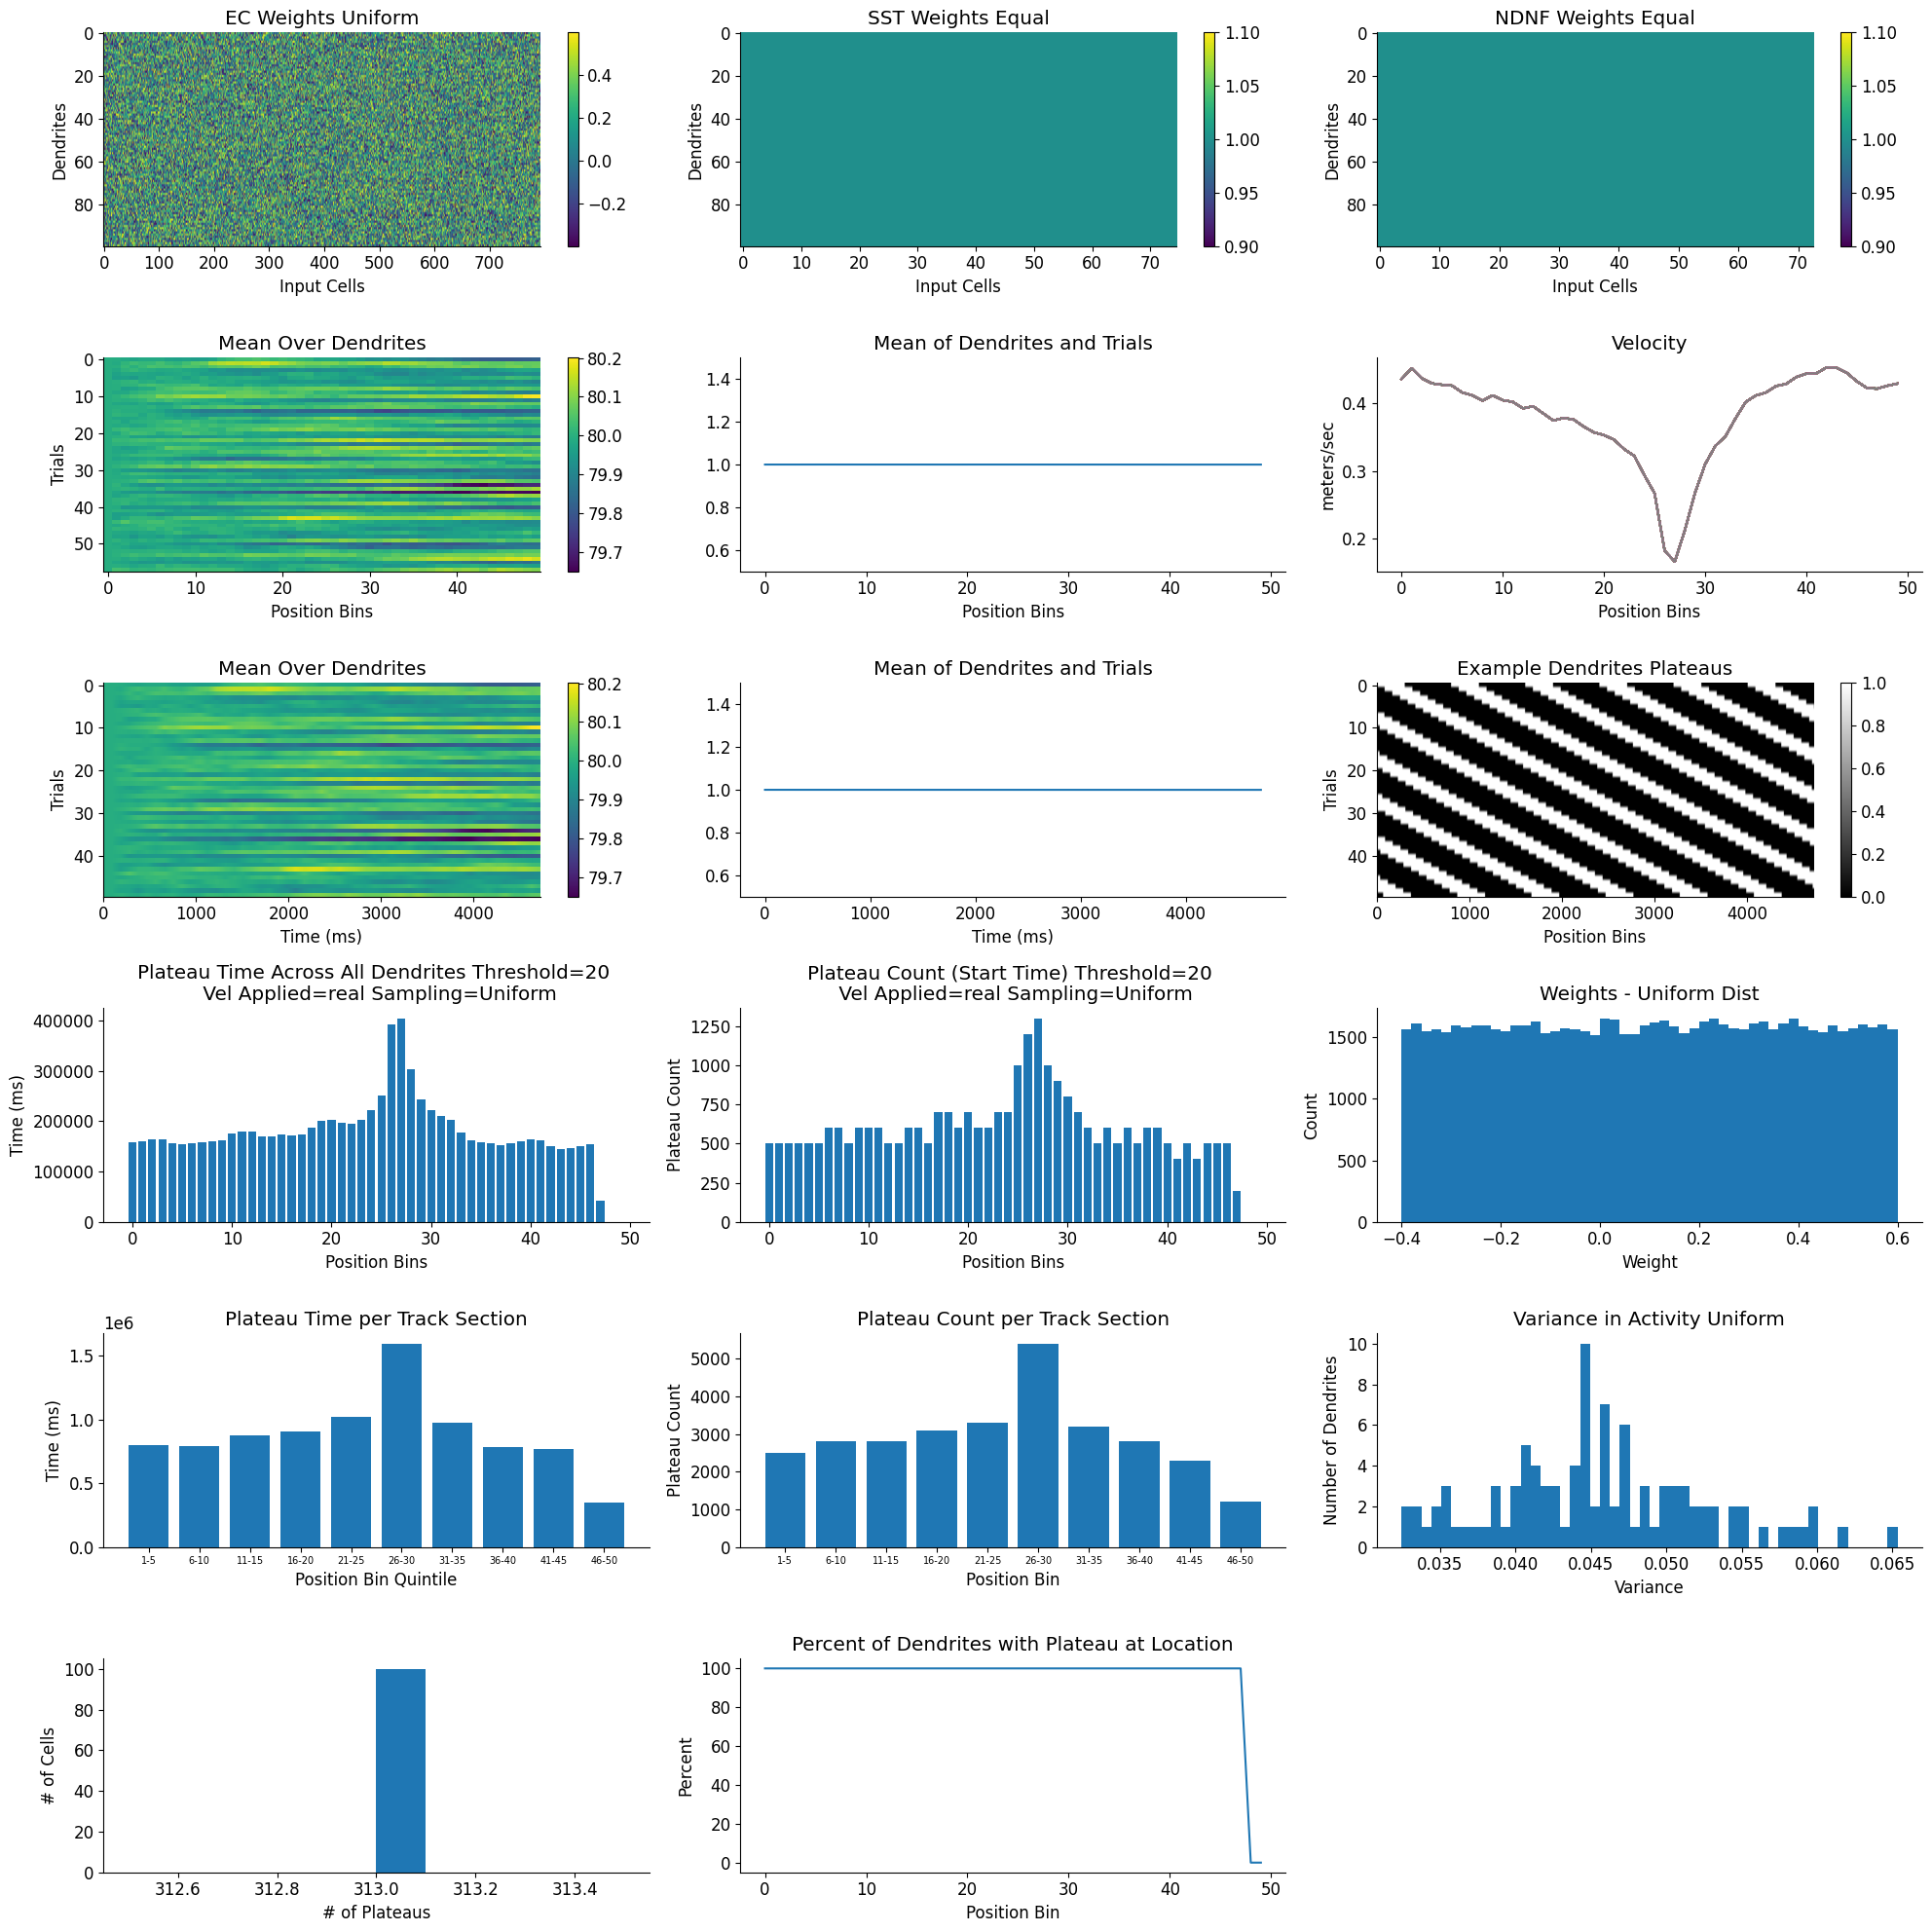

NameError: name 'activity_EC' is not defined

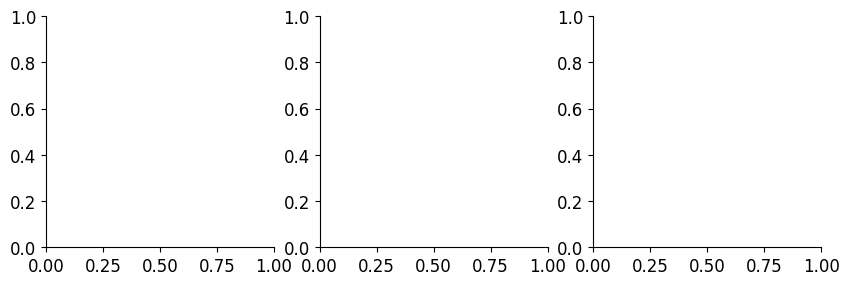

In [70]:


import random

def sample_equal_weights(mask, value=1.0):
    weights = np.zeros_like(mask, dtype=float)
    weights[mask] = value
    return weights

def sample_weights(distribution, mask, rng, mean=0.1, std=0.5):
    weights = np.zeros_like(mask, dtype=float)
    n_samples = np.sum(mask)

    if distribution == "Uniform":
        samples = rng.uniform(low=mean - std, high=mean + std, size=n_samples)
    elif distribution == "Normal":
        samples = rng.normal(loc=mean, scale=std, size=n_samples)
        samples = np.clip(samples, 0, None)
    elif distribution == "Lognormal":
        samples = rng.lognormal(mean=np.log(mean), sigma=std, size=n_samples)
    else:
        raise ValueError("Invalid distribution")

    weights[mask] = samples
    return weights


def get_dendrite_activity(weights, EC_input_matrix, n_dendrites, n_EC):
    EC_flat = EC_input_matrix.reshape(n_EC, -1)
    dendrite_flat = weights @ EC_flat
    return dendrite_flat.reshape(n_dendrites, 50, 58)

    
def loss_fn_multi(params, activity_EC, activity_SST, activity_NDNF):
    ndnf_sf, sst_sf = params
    summed = activity_EC - (sst_sf * activity_SST + ndnf_sf * activity_NDNF)
    
    summed_mean = np.mean(summed, axis=0)
    summed_means = np.mean(summed_mean, axis=1)
    summed_overall_means = np.mean(summed_means)
    
    main_loss = (summed_overall_means ** 2)  # This penalizes all deviations from 0

    return main_loss #+ 0.1 * equal_scaling_penalty


def random_timeseries(initial_value: float, volatility: float, count: int) -> list:
    time_series = [initial_value, ]
    for _ in range(count):
        time_series.append(time_series[-1] + initial_value * random.gauss(0, 1) * volatility)
    return time_series

            
    
    

vel_applied='real'

if vel_applied=="real":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True,  multiple_dendrites=True)
elif vel_applied=="constant":
    constant_vel=False
    real_vel=True
    dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True,  multiple_dendrites=True)
else:
    constant_vel=False
    real_vel=False
    dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=False,  multiple_dendrites=True)


    



def get_activity_multidendrite(dend_contribution_EC, an_velocity, EC_pop_list, NDNF_pop_list, SST_pop_list, dend_threshold=20, vel_applied="real", example_cell=15, dist="Uniform", n_dendrites=100, n_SST=75, n_EC=792, n_NDNF=73, include_inhibition=True, use_model_EC=False):

    SEED = 42
    np.random.seed(SEED)
    random.seed(SEED)
    rng = np.random.default_rng(SEED)
    
    
    EC_input_matrix = np.stack(EC_pop_list[:n_EC], axis=0)
    print(f"EC_input_matrix {EC_input_matrix.shape}")
    SST_input_matrix = np.stack(SST_pop_list[:n_SST], axis=0)
    NDNF_input_matrix = np.stack(NDNF_pop_list[:n_NDNF], axis=0)

    
    if use_model_EC:
        
        dend_list = []
        for j in range(792):
            ts_list = []
            for i in range(58):
                ts = random_timeseries(1.0, 0.005, 49)
                ts_list.append(ts)

            dend_contribution_EC = np.array(ts_list).T
            dend_list.append(dend_contribution_EC)
            
        EC_input_matrix = np.array(dend_list)
        print(f"EC_input_matrix.shape {EC_input_matrix.shape}")


    connection_mask_EC = np.ones((n_dendrites, n_EC), dtype=bool)
    connection_mask_SST = np.ones((n_dendrites, n_SST), dtype=bool)
    connection_mask_NDNF = np.ones((n_dendrites, n_NDNF), dtype=bool)

    weights_EC = sample_weights(dist, connection_mask_EC, rng=rng)
    weights_SST = sample_equal_weights(connection_mask_SST, 1.0)
    weights_NDNF = sample_equal_weights(connection_mask_NDNF, 1.0)


    activity_EC = get_dendrite_activity(weights_EC, EC_input_matrix, n_dendrites, n_EC)
    activity_SST = get_dendrite_activity(weights_SST, SST_input_matrix, n_dendrites, n_SST)
    activity_NDNF = get_dendrite_activity(weights_NDNF, NDNF_input_matrix, n_dendrites, n_NDNF)

    result = minimize(loss_fn_multi, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)], args=(activity_EC, activity_SST, activity_NDNF))
    NDNF_sf_opt, SST_sf_opt = result.x

    print(f"NDNF_sf_opt: {NDNF_sf_opt}")
    print(f"SST_sf_opt: {SST_sf_opt}")
    
    if include_inhibition:
        dend_activity = activity_EC - (activity_SST*SST_sf_opt + activity_NDNF*NDNF_sf_opt)
    else:
        dend_activity = activity_EC 
        


    plateau_positions_counter = np.zeros(50)
    plateau_start_positions_counter = np.zeros(50)

    threshold_list = []

    variance_list = []

    plateau_array_per_dendrite_list = []

    num_plateaus_per_dend_list = []

    dendrite_plateau_mask = np.zeros((dend_activity.shape[0], 50), dtype=bool)

    padded_warped_activity_list = []
    
    plateau_start_times_list_mega_list = []

    for d_idx in range(dend_activity.shape[0]):
        doi=dend_activity[d_idx,:,:]

        dt= 4.71657036/50
        dx=180/50

        animal_velocity_constant= np.full((doi.shape), dx/dt)

        proper_velocity = an_velocity*100


        dt_constant = 0.001

        if vel_applied=="constant":
            dt = dx / animal_velocity_constant
        else:
            dt = dx / proper_velocity
        time_bins = np.cumsum(dt, axis=0)
        time_bins_ms = time_bins * 1

        num_trials = dend_activity.shape[1]
        trial_warped_activity = []
        max_len = 0

        for t in range(num_trials):
            if np.any(np.isnan(time_bins[:, t])):
                continue
            total_time = time_bins[-1, t]

    #         print(f"{t} total time {total_time}")

            time_axis_constant = np.arange(0, total_time, dt_constant)

            firing = doi[:, t]

            warped_firing = np.interp(time_axis_constant, time_bins[:,t], firing)

            trial_warped_activity.append(warped_firing)
            if len(warped_firing) > max_len:
                max_len = len(warped_firing)

        padded_warped_activity = np.full((num_trials, max_len), np.nan) 
        for i, trace in enumerate(trial_warped_activity):
            padded_warped_activity[i, :len(trace)] = trace

        padded_warped_activity_list.append(padded_warped_activity)

        position_bins, num_trials = animal_velocity_constant.shape

        flat_padded_warped_activity = padded_warped_activity.flatten()
        flat_plateau_array = np.zeros_like(flat_padded_warped_activity)


        i = 0
        while i < len(flat_padded_warped_activity):
            if flat_padded_warped_activity[i] > dend_threshold:
                flat_plateau_array[i:i+300] = 1

                i += 800
            else:
                i += 100


        plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)
        plateau_array_per_dendrite_list.append(plateau_array)

        animal_velocity = proper_velocity

        plateau_start_times_list = []
        
        for trial in range(plateau_array.shape[0]):
            velocity_trial = animal_velocity[:, trial]
    #         velocity_trial = proper_velocity
            dt_trial = dx / velocity_trial  # in seconds
            time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

            plateau_start_indices = np.where(np.diff(np.pad(plateau_array[trial], (1, 0))) == 1)[0]
            plateau_start_times = plateau_start_indices * dt_constant  # in seconds
            plateau_start_times_list.append(plateau_start_times)

            for pt_start_time in plateau_start_times:
                if pt_start_time != 0.0:
                    for pos_idx in range(50):
                        if time_each_pos_bin_starts[pos_idx] <= pt_start_time < time_each_pos_bin_starts[pos_idx + 1]:
                            plateau_start_positions_counter[pos_idx] += 1
                            break
                            
        plateau_start_times_list_mega_list.append(plateau_start_times_list)

        num_plateaus_list = []
        for trial in range(plateau_array.shape[0]):
            velocity_trial = animal_velocity[:, trial]
    #         velocity_trial = proper_velocity
            dt_trial = dx / velocity_trial  # in seconds
            time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

            plateau_start_indices = np.where(np.diff(np.pad(plateau_array[trial], (1, 0))) == 1)[0]

            plateau_start_times = plateau_start_indices * dt_constant  # in seconds
            num_plateaus_list.append(len(plateau_start_times))

            for pt_start_time in plateau_start_times:
                if pt_start_time != 0.0:
                    for pos_idx in range(50):
                        if time_each_pos_bin_starts[pos_idx] <= pt_start_time < time_each_pos_bin_starts[pos_idx + 1]:
                            dendrite_plateau_mask[d_idx, pos_idx] = True
                            break

        num_plateaus_per_dend_list.append(np.sum(num_plateaus_list))





        num_time_bins = padded_warped_activity.shape[1]

        animal_velocity = proper_velocity


        num_trials, num_time_bins = plateau_array.shape
        position_bins = 50

        for trial in range(num_trials):
            velocity_trial = animal_velocity[:, trial]  # shape (50,)
            dt_trial = dx / velocity_trial              # shape (50,)
            bin_edges = np.concatenate([[0], np.cumsum(dt_trial)])  # shape (51,)

            time_bins = np.arange(num_time_bins) * dt_constant  # shape (num_time_bins,)

            plateau_indices = np.where(plateau_array[trial] == 1)[0]  # shape (n_plateaus,)

            if len(plateau_indices) == 0:
                continue

            pt_times = time_bins[plateau_indices] 

            pos_bin_idxs = np.searchsorted(bin_edges, pt_times, side='right') - 1

            valid_mask = (pos_bin_idxs >= 0) & (pos_bin_idxs < position_bins)
            pos_bin_idxs = pos_bin_idxs[valid_mask]

            bin_counts = np.bincount(pos_bin_idxs, minlength=position_bins)

            # --- Accumulate into global counter
            plateau_positions_counter += bin_counts
            
    plateau_start_times_list = plateau_start_times_list_mega_list[example_cell]
    
    EC_used = use_model_EC

    return weights_EC, weights_SST, weights_NDNF, padded_warped_activity_list, dend_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array_per_dendrite_list, dendrite_plateau_mask, time_each_pos_bin_starts, plateau_start_times_list, EC_used, dist, num_plateaus_per_dend_list
    

    
    
def plot_multidendrite(weights_EC, weights_SST, weights_NDNF, padded_warped_activity_list, an_velocity, dend_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array_per_dendrite_list, dendrite_plateau_mask, time_each_pos_bin_starts, plateau_start_times_list, EC_used, dist, num_plateaus_per_dend_list, scale_EC=True, example_cell=15):
    
    fig, axs = plt.subplots(6,3, figsize=(20,20))

    im1 = axs[0,0].imshow(weights_EC, aspect='auto')
    axs[0,0].set_title(f"EC Weights {dist}")
    axs[0,0].set_ylabel("Dendrites")
    axs[0,0].set_xlabel("Input Cells")
    fig.colorbar(im1, ax=axs[0,0])

    im2 = axs[0,1].imshow(weights_SST, aspect='auto')
    axs[0,1].set_title(f"SST Weights Equal")
    axs[0,1].set_ylabel("Dendrites")
    axs[0,1].set_xlabel("Input Cells")
    fig.colorbar(im2, ax=axs[0,1])

    im3 = axs[0,2].imshow(weights_NDNF, aspect='auto')
    axs[0,2].set_title(f"NDNF Weights Equal")
    axs[0,2].set_ylabel("Dendrites")
    axs[0,2].set_xlabel("Input Cells")
    fig.colorbar(im3, ax=axs[0,2])

    padded_warped_activity_array = np.array(padded_warped_activity_list)

    mean_pad = np.mean(padded_warped_activity_array, axis=0)

    im4 = axs[2,0].imshow(mean_pad, aspect='auto', interpolation='None')
    axs[2,0].set_title("Mean Over Dendrites")
    axs[2,0].set_ylabel("Trials")
    axs[2,0].set_xlabel("Time (ms)")
    fig.colorbar(im4, ax=axs[2,0])

    means = np.mean(mean_pad, axis=0)
    if EC_used:
        means = means / np.max(means)
    if scale_EC:
        axs[2,1].set_ylim(0.5,1.5)
    axs[2,1].plot(means)
    axs[2,1].set_title("Mean of Dendrites and Trials")
    axs[2,1].set_xlabel("Time (ms)")

    axs[1,2].plot(an_velocity)
    axs[1,2].set_xlabel("Position Bins")
    axs[1,2].set_ylabel("meters/sec")
    axs[1,2].set_title("Velocity")

    mean_dend_activity = np.mean(dend_activity, axis=0)

    im4 = axs[1,0].imshow(mean_dend_activity.T, aspect='auto')
    axs[1,0].set_title("Mean Over Dendrites")
    axs[1,0].set_ylabel("Trials")
    axs[1,0].set_xlabel("Position Bins")
    fig.colorbar(im4, ax=axs[1,0])

    means = np.nanmean(mean_dend_activity, axis=1)
    
    if EC_used:
        means = means / np.max(means)
    if scale_EC:
        axs[1,1].set_ylim(0.5,1.5)
    axs[1,1].plot(means)
    axs[1,1].set_title("Mean of Dendrites and Trials")
    axs[1,1].set_xlabel("Position Bins")

    print(f"means {np.nanmean(means)} mean_dend_activity {np.nanmean(mean_dend_activity)}")

    axs[3,0].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
    axs[3,0].set_title(f"Plateau Time Across All Dendrites Threshold={dend_threshold} \n Vel Applied={vel_applied} Sampling={dist}")
    axs[3,0].set_ylabel("Time (ms)")
    axs[3,0].set_xlabel("Position Bins")

    axs[3,1].bar(range(len(plateau_start_positions_counter)), plateau_start_positions_counter)
    axs[3,1].set_title(f"Plateau Count (Start Time) Threshold={dend_threshold} \n Vel Applied={vel_applied} Sampling={dist}")
    axs[3,1].set_ylabel("Plateau Count")
    axs[3,1].set_xlabel("Position Bins")


    n_bins = 10
    bin_size = int(50 / n_bins)

    summed_plateaus = np.zeros(n_bins)

    for i in range(n_bins):
        start = i * bin_size
        end = (i + 1) * bin_size
        summed_data = np.sum(plateau_positions_counter[start:end])
        summed_plateaus[i] = summed_data

    axs[4,0].bar(range(len(summed_plateaus)), summed_plateaus)
    axs[4,0].set_xlabel("Position Bin Quintile")
    axs[4,0].set_ylabel("Time (ms)")
    axs[4,0].set_title("Plateau Time per Track Section")
    axs[4,0].set_xticks(np.arange(n_bins), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"], fontsize=7)

    n_bins = 10
    bin_size = int(50 / n_bins)

    summed_plateaus = np.zeros(n_bins)

    for i in range(n_bins):
        start = i * bin_size
        end = (i + 1) * bin_size
        summed_data = np.sum(plateau_start_positions_counter[start:end])
        summed_plateaus[i] = summed_data

    axs[4,1].bar(range(len(summed_plateaus)), summed_plateaus)
    axs[4,1].set_xlabel("Position Bin")
    axs[4,1].set_ylabel("Plateau Count")
    axs[4,1].set_title("Plateau Count per Track Section")
    axs[4,1].set_xticks(np.arange(n_bins), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"], fontsize=7)


    axs[3,2].hist(weights_EC.flatten(), bins=50)
    axs[3,2].set_title(f"Weights - {dist} Dist")
    axs[3,2].set_ylabel("Count")
    axs[3,2].set_xlabel("Weight")

    variance_array = np.var(dend_activity, axis=(1, 2))  # Per dendrite variance

    print(f"variance_array.shape {variance_array.shape}")
    axs[4,2].hist(variance_array, bins=50)
    axs[4,2].set_title(f"Variance in Activity {dist}")
    axs[4,2].set_xlabel("Variance")
    axs[4,2].set_ylabel("Number of Dendrites")


    axs[5,0].hist(num_plateaus_per_dend_list, bins=10)
    axs[5,0].set_xlabel("# of Plateaus")
    axs[5,0].set_ylabel("# of Cells")

    number_dendrites_counter = np.sum(dendrite_plateau_mask, axis=0) # shape (50,)
    # plt.bar(range(len(number_dendrites_counter)), number_dendrites_counter)
    axs[5,1].plot(number_dendrites_counter)
    axs[5,1].set_title("Percent of Dendrites with Plateau at Location")
    axs[5,1].set_ylabel("Percent")
    axs[5,1].set_xlabel("Position Bin")

    ims = axs[2,2].imshow(plateau_array_per_dendrite_list[example_cell], aspect='auto', cmap='gray')
    axs[2,2].set_title("Example Dendrites Plateaus")
    axs[2,2].set_xlabel("Position Bins")
    axs[2,2].set_ylabel("Trials")
    fig.colorbar(ims, ax=axs[2,2])

    axs[5,2].axis('off')

    plt.tight_layout()
    plt.show()
    
    
    # final_bin = time_each_position_bin_starts[-1] *1000
    # timecourse = np.zeros(int(final_bin))
    # timecourse_bins = np.zeros(int(final_bin))
    
    # print(f"first bin {time_each_position_bin_starts[0]}")
    # print(f"final_bin {final_bin}")

    # plateau_start_times_list_cleaned = []
    # for trial in range(len(plateau_start_times_list)):
    #     if np.any(plateau_start_times_list[trial]!=0):
    #         for i in plateau_start_times_list[trial]:
    #             plateau_start_times_list_cleaned.append(int(i*1000))
                
    # print(f"plateau_start_times_list_cleaned {np.max(plateau_start_times_list_cleaned)}")


    # for plateau in plateau_start_times_list_cleaned:
    #     timecourse[plateau] = 1

    # # for bins in time_each_position_bin_starts:
    # #     if bins < time_each_position_bin_starts[-1]:
    # #         bins_scaled = int(bins*1000)
    # #         timecourse_bins[bins_scaled] = 2

    # plt.figure(figsize=(12,3))

    # # Plot dashed vertical red lines at bin starts
    # for bins in time_each_position_bin_starts:
    #     bins_scaled = int(bins * 1000)
    #     plt.vlines(bins_scaled, ymin=0, ymax=2, color='r', linestyle='--', alpha=0.6)
    # plt.plot(timecourse, alpha=0.6)
    # plt.title("Red=Position Bin in Time, Blue=Plateau Time")
    # plt.show()
    

    
    
    
weights_EC, weights_SST, weights_NDNF, padded_warped_activity_list, dend_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array_per_dendrite_list, dendrite_plateau_mask, time_each_pos_bin_starts, plateau_start_times_list, EC_used, dist, num_plateaus_per_dend_list = get_activity_multidendrite(dend_contribution_EC, an_velocity, dend_list_EC, dend_list_NDNF, dend_list_SST, dend_threshold=20, vel_applied="constant", example_cell=15, dist="Uniform", n_dendrites=100, n_SST=75, n_EC=792, n_NDNF=73, include_inhibition=False, use_model_EC=True)

plot_multidendrite(weights_EC, weights_SST, weights_NDNF, padded_warped_activity_list, an_velocity, dend_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array_per_dendrite_list, dendrite_plateau_mask, time_each_pos_bin_starts, plateau_start_times_list, EC_used, dist, num_plateaus_per_dend_list, scale_EC=True)
    

    


fig, axs = plt.subplots(1, 3, figsize=(10,3))

mean_dend_EC = np.mean(activity_EC, axis=0)
mean_dend_SST = np.mean(activity_SST, axis=0)
mean_dend_NDNF = np.mean(activity_NDNF, axis=0)

axs[0].plot(np.mean(mean_dend_EC[:,:10], axis=1), label="EC Early", color="g")
axs[0].plot(np.mean(mean_dend_EC[:,48:], axis=1), label="EC Late", color="limegreen")
axs[0].legend()

axs[1].plot(np.mean(mean_dend_SST[:,:10], axis=1), label="SST Early", color="b")
axs[1].plot(np.mean(mean_dend_SST[:,48:], axis=1), label="SST_late", color="cyan")
axs[1].legend()

axs[2].plot(np.mean(mean_dend_NDNF[:,:10], axis=1), label="NDNF Early", color='orange')
axs[2].plot(np.mean(mean_dend_NDNF[:,48:], axis=1), label="NDNF late", color='r')
axs[2].legend()

plt.tight_layout()
plt.show()

